In [ ]:
%pip install requirements.txt

In [2]:
import pandas as pd
import duckdb
import numpy as np

conn = duckdb.connect()


In [ ]:
# Read the entire parquet file
df = pd.read_parquet("../data/faculty-salaries.parquet")

In [4]:
df.head()

,name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year
0,alice m burton,accountant i,NaN,47748,0,275,NaN,48023,0,48023,2011
1,dagoberto escobedo,accountant i,NaN,48420,314,0,NaN,48734,0,48734,2011
2,terri l porter,accountant i,NaN,47076,0,0,NaN,47076,0,47076,2011
3,cynthia e williams,accountant i,NaN,51552,0,600,NaN,52152,0,52152,2011
4,mandy t wong,accountant i,NaN,44400,0,0,NaN,44400,0,44400,2011


No rows with ual, benefitsee, benefitser, benefitsdc

In [5]:
df.count()

name                5322827
job                 5322827
department                0
base                5322827
overtime            5322827
other               5322827
notes                 28458
totalpay            5322827
totalbenefits       5322827
totalpaybenefits    5322827
year                5322827
dtype: int64

Some values have a total pay that is negative. Why is this? Should they just be removed? Also do we want to do any filtering on jobs? 

In [6]:
pay_less_than_0 = df[df['totalpay'] < 0]
pay_less_than_0.head()

,name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year
1239,david s harmer,carpenter,NaN,-221,49,9,NaN,-163,0,-163,2011
1471,john r sandhagen,"equipment technician i, specialized equipment",NaN,0,0,-153,NaN,-153,0,-153,2011
3943,jamie l corley,administrative support assistant -12 month,NaN,-1991,0,0,NaN,-1991,0,-1991,2011
6207,thomas e hawkins,lecturer - academic year,NaN,-114,0,0,NaN,-114,0,-114,2011
6826,andrea l brauninger,physician,NaN,-221,0,0,NaN,-221,0,-221,2011


In [7]:
rows_with_notes = df.dropna(subset=['notes'])
rows_with_notes.head()

,name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year
148954,leobigildo cota jr,administrator i,NaN,9530,0,8,employee holds multiple positions.,9538,3344,12882,2013
149008,kathy a fernandes,administrator ii,NaN,122687,0,35397,employee holds multiple positions.,158085,47011,205097,2013
149009,kathleen l flachmeier,administrator ii,NaN,6276,0,27067,employee holds multiple positions.,33343,2300,35643,2013
149054,sabrina k sanders,administrator ii,NaN,69412,0,60,employee holds multiple positions.,69472,22435,91908,2013
149121,robin d innes,administrator iii,NaN,95384,0,1008,employee holds multiple positions.,96392,27698,124091,2013


In [8]:
#clean dataset, remove rows missing name or totalpay
clean_df = df.dropna(subset=['name', 'totalpay'])
#remove total pay under baseline salary (start 10,000)
clean_df = clean_df[clean_df['totalpay'] >= 10000]
clean_df.count()

name                3522271
job                 3522271
department                0
base                3522271
overtime            3522271
other               3522271
notes                 25982
totalpay            3522271
totalbenefits       3522271
totalpaybenefits    3522271
year                3522271
dtype: int64

In [9]:
col = df["totalpay"]

col.mean()                                         # center — sensitive
col.median()                                       # center — robust
col.std()    
col.min()
col.max()                                        # spread — sensitive
print("Mean:", col.mean())
print("Median:", col.median())
print("Standard Deviation:", col.std())
print("Minimum:", col.min())
print("Maximum:", col.max())
print("IQR:", col.quantile(0.75) - col.quantile(0.25))


Mean: 51895.96413109049
Median: 32376.0
Standard Deviation: 71000.34076838756
Minimum: -331742
Maximum: 7061667
IQR: 67469.0


In [10]:
result_df = duckdb.query("""
SELECT * from df
WHERE department != 'NaN' AND name != 'No records found.'
""").df()
result_df.head()
#result_df.count()

,name,job,department,base,overtime,other,notes,totalpay,totalbenefits,totalpaybenefits,year


In [11]:
result_df = duckdb.query("""
SELECT DISTINCT department from df
""").df()
result_df.head(10)
result_df.count()

department    0
dtype: int64

In [ ]:
#join faculty-compensation.parquet with cal_poly_faculty.parquet (name = employee)


df1 = pd.read_parquet("../data/faculty-compensation.parquet")
df2 = pd.read_parquet("../data/cal_poly_faculty.parquet")


df_joined = pd.merge(
    df1,
    df2,
    left_on="employee",
    right_on="name",
    how="left"
)

df_joined.count()

employee           4985
FY 22-23           4985
FY 23-24           4985
FY 24-25           4985
name                152
year_hired          152
department          152
position            152
education           152
email               152
phone               152
catalog_section     152
name_raw            152
source_url          152
retrieved_at        152
dtype: int64

In [17]:
df1.head()

,employee,FY 22-23,FY 23-24,FY 24-25
0,"Abba, Michele M",62096.0,64516.60,67836.00
1,"Abdelhafeez, Laila Maher",0.0,0.00,42000.00
2,"Abdullah, Shahnaz T",0.0,91630.00,111562.00
3,"Abeloos, Diego V.",75807.0,97900.00,99228.00
4,"Abercromby, Kira Jorgensen",128576.0,134435.09,142673.48


In [18]:
df2.head()

,name,year_hired,department,position,education,email,phone,catalog_section,name_raw,source_url,retrieved_at
0,"Abdelhafeez, Laila M.",2025.0,Computer Science,Assistant Professor,"B.S., Cairo University, 2017; M.S., University...",,,Faculty Directory,"Abdelhafeez, Laila M. (2025) \nComputer Science",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
1,"Abercromby, Kira J.",2008.0,Aerospace Engineering,Professor,"B.S., University of California, Los Angeles, 1...",,,Faculty Directory,"Abercromby, Kira J. (2008) \nAerospace Enginee...",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
2,"Abeysiridara Samarakoon, Radhavi",2026.0,Civil and Environmental Engineering,Assistant Professor,"B.S., University of Moratuwa, Sir Lanka, 2014;...",,,Faculty Directory,"Abeysiridara Samarakoon, Radhavi (2026) \nCivi...",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
3,"Abo Ismail, Mohammed",2019.0,Animal Science,Associate Professor,"B.S., Alexandria University Damanhour, 2000; M...",,,Faculty Directory,"Abo Ismail, Mohammed (2019) \nAnimal Science",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00
4,"Abril Valenzuela, Roberto",2026.0,Physics,Assistant Professor,"B.S., Physics, B.S., Mathematics, California P...",,,Faculty Directory,"Abril Valenzuela, Roberto (2026) \nPhysics",https://catalog.calpoly.edu/faculty-staff/,2026-09-15 05:06:23.673142+00:00


In [ ]:
import pandas as pd

df1 = pd.read_parquet("../data/faculty-compensation.parquet")
df2 = pd.read_parquet("../data/cal_poly_faculty.parquet")

def split_name(df, source_column, prefix):
    parts = (
        df[source_column]
        .fillna("")
        .str.replace(r"[.,]", "", regex=True)
        .str.strip()
        .str.lower()
        .str.split()
    )

    df[f"{prefix}_first"] = parts.str[1]
    df[f"{prefix}_middle"] = parts.str[-1].where(parts.str.len() >= 3)
    df[f"{prefix}_last"] = parts.str[0]

split_name(df1, "employee", "employee")
split_name(df2, "name", "faculty")

df_joined = df1.merge(
    df2,
    left_on=["employee_first", "employee_last"],
    right_on=["faculty_first", "faculty_last"],
    how="left"
)

df_joined[[
    "employee_first", "employee_middle", "employee_last",
    "faculty_first", "faculty_middle", "faculty_last"
]].head()

,employee_first,employee_middle,employee_last,faculty_first,faculty_middle,faculty_last
0,michele,m,abba,NaN,NaN,NaN
1,laila,maher,abdelhafeez,laila,m,abdelhafeez
2,shahnaz,t,abdullah,NaN,NaN,NaN
3,diego,v,abeloos,NaN,NaN,NaN
4,kira,jorgensen,abercromby,kira,j,abercromby


In [20]:
df_joined.count()

employee           4985
FY 22-23           4985
FY 23-24           4985
FY 24-25           4985
employee_first     4985
employee_middle    4406
employee_last      4985
name                681
year_hired          679
department          681
position            681
education           681
email               681
phone               681
catalog_section     681
name_raw            681
source_url          681
retrieved_at        681
faculty_first       681
faculty_middle      329
faculty_last        681
dtype: int64

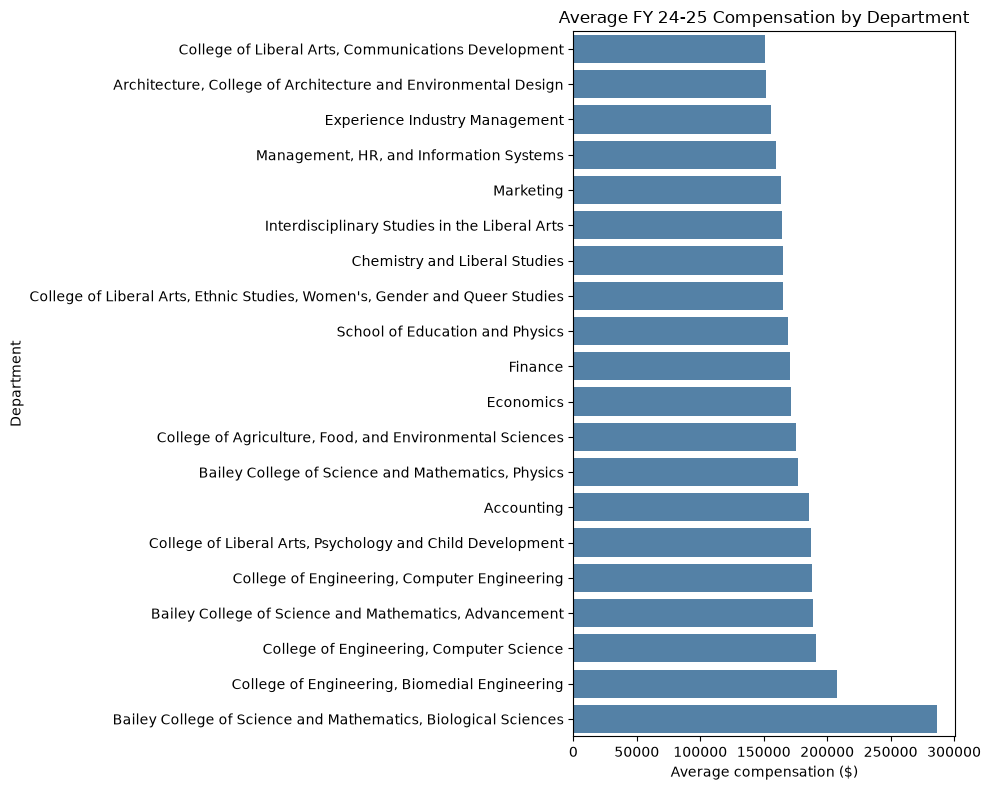

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_column = "FY 24-25"
plot_df = df_joined[["department", pay_column]].copy()
plot_df[pay_column] = (
    plot_df[pay_column]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .replace("nan", pd.NA)
    .astype(float)
)
plot_df = plot_df.dropna(subset=["department", pay_column])

# Average pay by department; limit to the 20 departments with the most matched faculty.
department_pay = (
    plot_df.groupby("department", as_index=False)[pay_column]
    .mean()
    .nlargest(20, pay_column)
    .sort_values(pay_column)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=department_pay, x=pay_column, y="department", color="steelblue")
plt.title(f"Average {pay_column} Compensation by Department")
plt.xlabel("Average compensation ($)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()



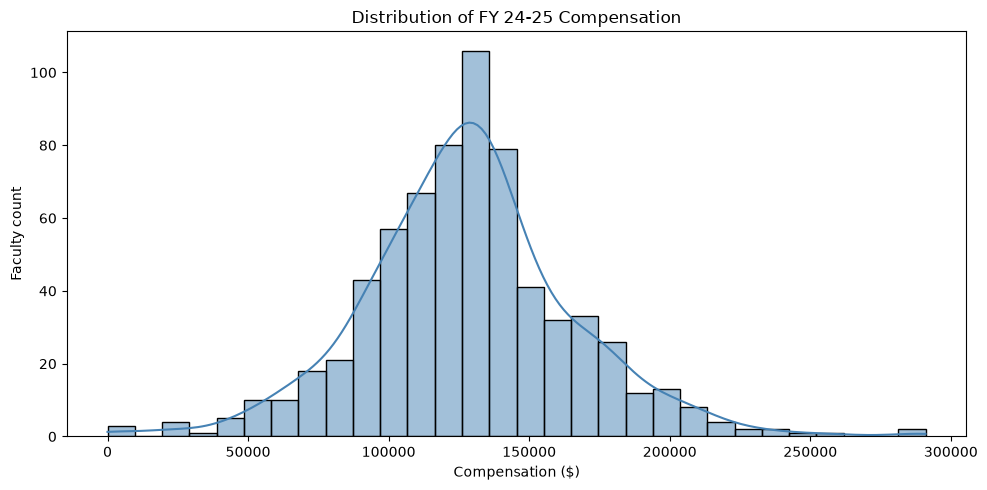

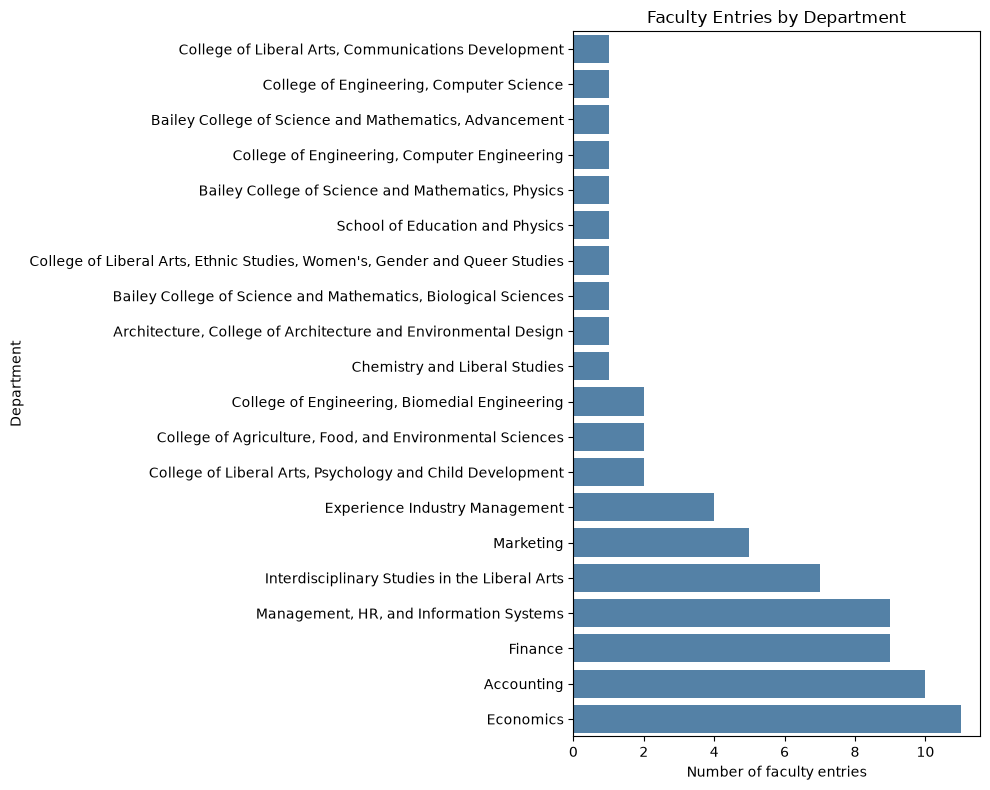

In [22]:
#plot of pay and count
# Overall pay distribution.
plt.figure(figsize=(10, 5))
sns.histplot(plot_df[pay_column], bins=30, kde=True, color="steelblue")
plt.title(f"Distribution of {pay_column} Compensation")
plt.xlabel("Compensation ($)")
plt.ylabel("Faculty count")
plt.tight_layout()
plt.show()

# Number of joined faculty entries in each department (top 20).
department_counts = (
    plot_df[plot_df["department"].isin(department_pay["department"])]
    ["department"]
    .value_counts()
    .reindex(department_pay["department"])
    .sort_values()
)
plt.figure(figsize=(10, 8))
sns.barplot(x=department_counts.values, y=department_counts.index, color="steelblue")
plt.title("Faculty Entries by Department")
plt.xlabel("Number of faculty entries")
plt.ylabel("Department")
plt.tight_layout()
plt.show()
